In [1]:
import os
os.chdir('../../..')

In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import kmedoids
import chemiscope

from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from tqdm import tqdm
from umap import UMAP
from persim import plot_diagrams

from src.datasets import QM9Dataset
from src.features import MolecularFeaturizer
from src.non_euclidean import Grassmann, Riemann, PersistentHomology
from src.clusters import MolecularClusterScore, calculate_congruence

In [3]:
qm9 = QM9Dataset()
qm9.load()
qm9.add_soap()

2026-03-21 15:07:28.070 | INFO     | src.datasets:load:381 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-21 15:07:28.156 | INFO     | src.features:compute_soap:144 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-03-21 15:07:36.882 | SUCCESS  | src.datasets:add_soap:603 - Added SOAP embeddings.


In [4]:
qm9.df.tail(3)

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64]
"""qm9_2232""","""C4H6O3""","""[H]C(=O)OC1([H])C([H])([H])OC1…","""[H]C(=O)OC1([H])C([H])([H])OC1…","""[H][C][=Branch1][C][=O][O][C][…","""ether""",13,"""Aliphatic Ring""",102,0,35,7,1,0,1,0.0,0.25,0.75,0,3,4,0,1,3,5,25,1.272069,0,0,0,0,0,0,0,0,2,0,3,2.762,51.860001,-7.235507,-0.059865,7.175642,893.72937,2.746336,-10383.348633,-10383.164062,-10383.138672,-10384.21582,22.610001,-54.383949,-54.699978,-55.008392,-50.708042,9.96411,1.33561,1.25859,"[0.107325, 0.293417, … 0.0]"
"""qm9_2233""","""C7H10""","""[H]C([H])([H])C#CC1([H])C([H])…","""[H]C([H])([H])C#CC1([H])C([H])…","""[H][C][Branch1][C][H][Branch1]…","""""",17,"""Aliphatic Ring""",94,1,0,7,1,0,0,0.285714,0.0,0.714286,0,0,5,2,0,5,7,35,1.251378,0,0,0,0,0,0,0,0,0,0,0,0.1237,74.040001,-6.449099,1.548328,7.997427,1100.771851,4.030632,-7416.551758,-7416.336426,-7416.311035,-7417.458496,27.582001,-71.378632,-71.818748,-72.229988,-66.61631,8.78858,1.18031,1.11373,"[0.136693, 0.367909, … 0.0]"
"""qm9_2234""","""C6H8O""","""[H]C([H])([H])C#C[C@]1([H])OC(…","""[H]C([H])([H])C#C[C@]1([H])OC(…","""[H][C][Branch1][C][H][Branch1]…","""ether""",15,"""Aliphatic Ring""",96,0,9,7,1,0,0,0.333333,0.0,0.666667,0,1,4,2,0,4,7,29,1.25409,0,0,0,0,0,0,0,0,1,0,1,1.8317,66.43,-6.593319,0.800015,7.393333,1023.46698,3.376089,-8393.930664,-8393.71875,-8393.692383,-8394.857422,25.872,-63.23584,-63.601395,-63.961239,-59.061749,8.5118,1.25072,1.19183,"[0.123785, 0.333426, … 0.0]"


In [5]:
row = 0
num_molecules = None

# add molecular formula to find isomers
df = qm9.df

min_isomers = 30
formula_counts = df.group_by("formula").len().sort("len", descending=True)

display(formula_counts.head(10))

eligible = formula_counts.filter(pl.col("len") >= min_isomers)
if eligible.is_empty():
    raise ValueError(f"No formulas found with at least {min_isomers} isomers")

target_formula = eligible.row(row)[0]

isomers_df = df.filter(pl.col("formula") == target_formula)

def format_chemical(formula):
    return re.sub(r'(\d+)', lambda m: m.group(1).translate(str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")), formula)

print(f"Selected formula: {format_chemical(target_formula)} (n={isomers_df.height})")

formula,len
str,u32
"""C6H10O""",87
"""C5H10O2""",83
"""C5H7NO""",79
"""C5H8O2""",75
"""C6H12O""",62
"""C4H6N2O""",53
"""C5H9NO""",53
"""C6H8O""",51
"""C4H5NO2""",48


Selected formula: C₆H₁₀O (n=87)


In [6]:
isomers_df.head(5)

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64]
"""qm9_1056""","""C6H10O""","""[H]OC(C#CC([H])([H])[H])(C([H]…","""[H]OC(C#CC([H])([H])[H])(C([H]…","""[H][O][C][Branch1][O][C][#C][C…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,3,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.221356,0,1,0,0,0,0,0,0,0,0,1,1.3077,69.099998,-6.601482,1.366012,7.967494,1005.311523,3.931338,-8427.34668,-8427.092773,-8427.066406,-8428.299805,32.465,-69.425476,-69.826736,-70.238007,-64.698151,4.63514,1.37628,1.36228,"[0.135988, 0.361658, … 0.0]"
"""qm9_1059""","""C6H10O""","""[H]C#CC([H])([H])C(O[H])(C([H]…","""[H]C#CC([H])([H])C(O[H])(C([H]…","""[H][C][#C][C][Branch1][C][H][B…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,4,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.221311,0,1,0,0,0,0,0,0,0,0,1,1.8257,65.739998,-6.963394,1.390502,8.353896,842.739197,3.930902,-8427.166016,-8426.927734,-8426.902344,-8428.041992,32.365002,-69.244415,-69.661972,-70.073242,-64.440979,4.55848,1.70964,1.67157,"[0.136008, 0.365263, … 0.0]"
"""qm9_1103""","""C6H10O""","""[H]C([H])([H])C1(C([H])([H])[H…","""[H]C([H])([H])C1(C([H])([H])[H…","""[H][C][Branch1][C][H][Branch1]…","""ketone""",17,"""Aliphatic Ring""",98,1,17,7,1,0,2,0.0,0.166667,0.833333,0,1,6,0,1,5,5,37,1.250139,0,0,0,0,0,0,0,1,0,0,1,2.9233,64.370003,-6.492637,-0.465315,6.027322,792.775574,3.977679,-8428.405273,-8428.200195,-8428.174805,-8429.266602,28.490999,-70.484489,-70.933968,-71.345238,-65.66497,4.92901,1.86219,1.77689,"[0.136381, 0.364002, … 0.0]"
"""qm9_1135""","""C6H10O""","""[H]C#CC(C([H])([H])[H])(C([H])…","""[H]C#CC(C([H])([H])[H])(C([H])…","""[H][C][#C][C][Branch1][=Branch…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,4,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.221662,0,1,0,0,0,0,0,0,0,0,1,1.2828,65.860001,-7.080402,1.428598,8.509001,820.219421,3.94663,-8426.979492,-8426.738281,-8426.711914,-8427.859375,32.249001,-69.058395,-69.472282,-69.883553,-64.258087,3.943,1.84396,1.74441,"[0.13586, 0.365704, … 0.0]"
"""qm9_1145""","""C6H10O""","""[H]C#C[C@@](O[H])(C([H])([H])[…","""[H]C#C[C@@](O[H])(C([H])([H])[…","""[H][C][#C][C@@][Branch1][Ring1…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,4,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.22371,0,1,0,0,0,0,0,0,0,0,1,1.1577,65.989998,-7.153873,1.039475,8.19607,834.219421,3.941651,-8427.080078,-8426.841797,-8426.816406,-8427.958984,32.264,-69.158974,-69.575737,-69.986984,-64.356621,4.01944,1.84116,1.71261,"[0.136103, 0.365307, … 0.0]"


In [7]:
original_df = qm9.df
qm9.df = isomers_df
frames = qm9.get_positions(
    subset_size=isomers_df.height,
    output_filename="qm9_isomers.xyz"
)
qm9.df = original_df

print(f"Generated {len(frames)} frames for isomer set")

2026-03-21 15:07:39.093 | SUCCESS  | src.datasets:get_positions:928 - Saved 87 molecules to data/QM9/qm9_isomers.xyz (failed: 0, requested: 87).


Generated 87 frames for isomer set


In [8]:
# grassmann distance on ASE frames
grassmann_dist = Grassmann.distance_matrix(frames)
riemann_dist = Riemann.distance_matrix(frames, 'affine-invariant')
ph_dist = PersistentHomology.distance_matrix(frames, 'sliced-wasserstein')

# SOAP features from SMILES
soap_series = MolecularFeaturizer.compute_soap(isomers_df["canonical_smiles"])
soap_list = soap_series.to_list()

valid_idx = [i for i, v in enumerate(soap_list) if v is not None]

if len(valid_idx) < 3:
    raise ValueError("Too few valid SOAP features to cluster")

isomers_df = isomers_df[valid_idx]

frames = [frames[i] for i in valid_idx]
grassmann_dist = grassmann_dist[np.ix_(valid_idx, valid_idx)]

2026-03-21 15:07:39.601 | INFO     | src.non_euclidean:distance_matrix:337 - Computing Grassmann distance matrix for 87 frames (k=3, method='svd', normalized=False).
Grassmann distances: 100%|██████████| 3741/3741 [00:00<00:00, 10127.51pair/s]
2026-03-21 15:07:40.060 | SUCCESS  | src.non_euclidean:distance_matrix:351 - Finished Grassmann distance matrix computation.
2026-03-21 15:07:40.061 | INFO     | src.non_euclidean:distance_matrix:460 - Computing Riemannian distance matrix for 87 frames (metric='affine-invariant', normalized=False)
Riemann distances: 100%|██████████| 3741/3741 [00:00<00:00, 39616.66pair/s]
2026-03-21 15:07:40.221 | SUCCESS  | src.non_euclidean:distance_matrix:524 - Finished Riemannian distance matrix computation.
2026-03-21 15:07:40.221 | INFO     | src.non_euclidean:distance_matrix:262 - Computing persistent homology distance matrix for 87 frames (metric='sliced-wasserstein', max_homology_dim=2, dims=(0, 1, 2)).
2026-03-21 15:07:40.224 | INFO     | src.non_euclid

In [9]:
soap_dist = squareform(pdist(soap_list, metric='cosine'))

In [10]:
def evaluate_clustering_methods(distance_matrices, k_range=range(2, 15), random_state=42):
    results = {name: {"inertia": [], "silhouette": [], "ch": []} for name in distance_matrices}

    for k in tqdm(k_range, desc="Testing Cluster Counts"):
        for name, dist_matrix in distance_matrices.items():
            
            model = kmedoids.KMedoids(n_clusters=k, metric="precomputed", random_state=random_state)
            labels = model.fit_predict(dist_matrix)
            medoid_indices = model.medoid_indices_
            
            inertia = sum(dist_matrix[i, medoid_indices[labels[i]]] for i in range(len(labels)))
            
            sil = silhouette_score(dist_matrix, labels, metric='precomputed')
            
            ch = calinski_harabasz_score(dist_matrix, labels)

            results[name]["inertia"].append(inertia)
            results[name]["silhouette"].append(sil)
            results[name]["ch"].append(ch)
            
    return results

matrices = {
    "Grassmann": grassmann_dist,
    "Riemann": riemann_dist,
    "SOAP": soap_dist,
    "Persistent Homology": ph_dist  
}
k_range = range(2, 15)
evaluation_results = evaluate_clustering_methods(matrices, k_range)

Testing Cluster Counts: 100%|██████████| 13/13 [00:00<00:00, 203.89it/s]


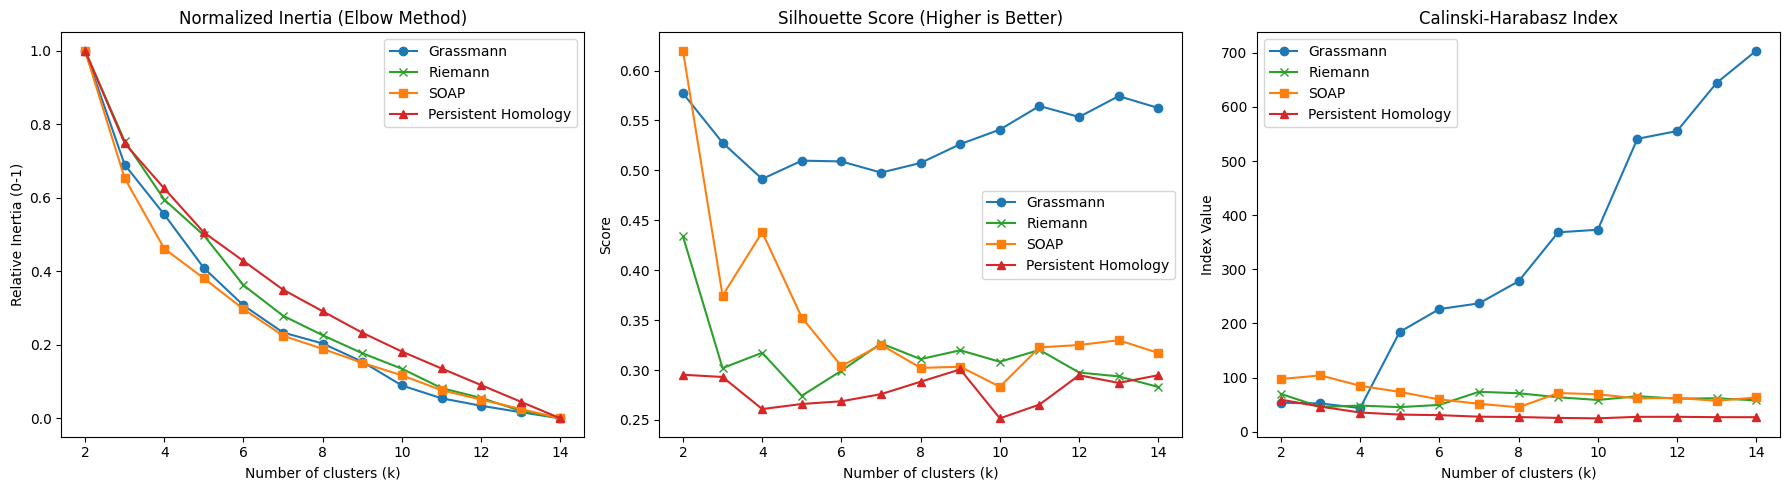

In [11]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'Grassmann': 'tab:blue', 'Riemann': 'tab:green', 
          'SOAP': 'tab:orange', 'Persistent Homology': 'tab:red'}
markers = {'Grassmann': 'o', 'Riemann': 'x', 
           'SOAP': 's', 'Persistent Homology': '^'}

ax0 = axes[0]
for name in evaluation_results:
    raw_inertia = np.array(evaluation_results[name]["inertia"])
    norm_inertia = (raw_inertia - raw_inertia.min()) / (raw_inertia.max() - raw_inertia.min())
    
    ax0.plot(k_range, norm_inertia, label=name, 
             marker=markers.get(name, 'd'), color=colors.get(name))

ax0.set_title('Normalized Inertia (Elbow Method)')
ax0.set_xlabel('Number of clusters (k)')
ax0.set_ylabel('Relative Inertia (0-1)')
ax0.legend()

ax1 = axes[1]
for name in evaluation_results:
    ax1.plot(k_range, evaluation_results[name]["silhouette"], label=name, 
             marker=markers.get(name, 'd'), color=colors.get(name))

ax1.set_title('Silhouette Score (Higher is Better)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Score')
ax1.legend()

ax2 = axes[2]
for name in evaluation_results:
    ax2.plot(k_range, evaluation_results[name]["ch"], label=name, 
             marker=markers.get(name, 'd'), color=colors.get(name))

ax2.set_title('Calinski-Harabasz Index')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Index Value')
ax2.legend()

plt.tight_layout()
plt.show()

In [12]:
evaluation_results.keys()

dict_keys(['Grassmann', 'Riemann', 'SOAP', 'Persistent Homology'])

In [13]:
num_clusters_grassmann = [i+2 for i, num in enumerate(evaluation_results['Grassmann']['silhouette']) if num==max(evaluation_results['Grassmann']['silhouette'])][0]
num_clusters_riemann = [i+2 for i, num in enumerate(evaluation_results['Riemann']['silhouette']) if num==max(evaluation_results['Riemann']['silhouette'])][0]
num_clusters_ph = [i+2 for i, num in enumerate(evaluation_results['Persistent Homology']['silhouette']) if num==max(evaluation_results['Persistent Homology']['silhouette'])][0]
num_clusters_soap = [i+2 for i, num in enumerate(evaluation_results['SOAP']['silhouette']) if num==max(evaluation_results['SOAP']['silhouette'])][0]

print(f"Number of clusters for Grassmann: {num_clusters_grassmann} \nNumber of clusters for SOAP: {num_clusters_soap} \nNumber of clusters for Riemann: {num_clusters_riemann} \nNumber of cluster Persistent Homology: {num_clusters_ph} ")

Number of clusters for Grassmann: 2 
Number of clusters for SOAP: 2 
Number of clusters for Riemann: 2 
Number of cluster Persistent Homology: 9 


In [14]:
def cluster_precomputed(dist_matrix: np.ndarray, n_clusters: int):
    model = kmedoids.KMedoids(n_clusters=n_clusters, metric="precomputed", random_state=42)
    return model.fit_predict(dist_matrix)

labels_grass = cluster_precomputed(grassmann_dist, n_clusters=2)
labels_riemann = cluster_precomputed(riemann_dist, n_clusters=2)
labels_ph = cluster_precomputed(ph_dist, n_clusters=num_clusters_ph)
labels_soap = cluster_precomputed(soap_dist, n_clusters=num_clusters_soap)

isomers_df = isomers_df.with_columns([
    pl.Series("cluster_grass", labels_grass),
    pl.Series("cluster_riemann", labels_riemann),
    pl.Series("cluster_soap", labels_soap),
    pl.Series("cluster_ph", labels_ph),
])

reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
X_grass_u = reducer.fit_transform(grassmann_dist)
X_riemann_u = reducer.fit_transform(riemann_dist)
X_ph_u = reducer.fit_transform(ph_dist)
X_soap_U = reducer.fit_transform(soap_dist)

tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state=42, perplexity=30)
X_grass_t = tsne.fit_transform(grassmann_dist)
X_riemann_t = tsne.fit_transform(riemann_dist)
X_ph_t = tsne.fit_transform(ph_dist)
X_soap_t = tsne.fit_transform(soap_dist)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [15]:
isomers_df.head(5)

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding,cluster_grass,cluster_riemann,cluster_soap,cluster_ph
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64],u64,u64,u64,u64
"""qm9_1056""","""C6H10O""","""[H]OC(C#CC([H])([H])[H])(C([H]…","""[H]OC(C#CC([H])([H])[H])(C([H]…","""[H][O][C][Branch1][O][C][#C][C…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,3,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.221356,0,1,0,0,0,0,0,0,0,0,1,1.3077,69.099998,-6.601482,1.366012,7.967494,1005.311523,3.931338,-8427.34668,-8427.092773,-8427.066406,-8428.299805,32.465,-69.425476,-69.826736,-70.238007,-64.698151,4.63514,1.37628,1.36228,"[0.135988, 0.361658, … 0.0]",0,1,1,1
"""qm9_1059""","""C6H10O""","""[H]C#CC([H])([H])C(O[H])(C([H]…","""[H]C#CC([H])([H])C(O[H])(C([H]…","""[H][C][#C][C][Branch1][C][H][B…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,4,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.221311,0,1,0,0,0,0,0,0,0,0,1,1.8257,65.739998,-6.963394,1.390502,8.353896,842.739197,3.930902,-8427.166016,-8426.927734,-8426.902344,-8428.041992,32.365002,-69.244415,-69.661972,-70.073242,-64.440979,4.55848,1.70964,1.67157,"[0.136008, 0.365263, … 0.0]",1,1,0,1
"""qm9_1103""","""C6H10O""","""[H]C([H])([H])C1(C([H])([H])[H…","""[H]C([H])([H])C1(C([H])([H])[H…","""[H][C][Branch1][C][H][Branch1]…","""ketone""",17,"""Aliphatic Ring""",98,1,17,7,1,0,2,0.0,0.166667,0.833333,0,1,6,0,1,5,5,37,1.250139,0,0,0,0,0,0,0,1,0,0,1,2.9233,64.370003,-6.492637,-0.465315,6.027322,792.775574,3.977679,-8428.405273,-8428.200195,-8428.174805,-8429.266602,28.490999,-70.484489,-70.933968,-71.345238,-65.66497,4.92901,1.86219,1.77689,"[0.136381, 0.364002, … 0.0]",0,0,0,2
"""qm9_1135""","""C6H10O""","""[H]C#CC(C([H])([H])[H])(C([H])…","""[H]C#CC(C([H])([H])[H])(C([H])…","""[H][C][#C][C][Branch1][=Branch…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,4,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.221662,0,1,0,0,0,0,0,0,0,0,1,1.2828,65.860001,-7.080402,1.428598,8.509001,820.219421,3.94663,-8426.979492,-8426.738281,-8426.711914,-8427.859375,32.249001,-69.058395,-69.472282,-69.883553,-64.258087,3.943,1.84396,1.74441,"[0.13586, 0.365704, … 0.0]",0,0,0,1
"""qm9_1145""","""C6H10O""","""[H]C#C[C@@](O[H])(C([H])([H])[…","""[H]C#C[C@@](O[H])(C([H])([H])[…","""[H][C][#C][C@@][Branch1][Ring1…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,4,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.22371,0,1,0,0,0,0,0,0,0,0,1,1.1577,65.989998,-7.153873,1.039475,8.19607,834.219421,3.941651,-8427.080078,-8426.841797,-8426.816406,-8427.958984,32.264,-69.158974,-69.575737,-69.986984,-64.356621,4.01944,1.84116,1.71261,"[0.136103, 0.365307, … 0.0]",1,1,0,1


In [16]:
print("--- Grassmann Clustering Results ---")
for cluster_id in range(num_clusters_grassmann):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_grass") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")

print("\n" + "="*50 + "\n")

print("--- Riemann Clustering Results ---")
for cluster_id in range(num_clusters_riemann):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_riemann") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")

print("\n" + "="*50 + "\n")
print("--- PH Clustering Results ---")
for cluster_id in range(num_clusters_ph):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_ph") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")


print("\n" + "="*50 + "\n")

print("--- SOAP Clustering Results ---")
for cluster_id in range(num_clusters_soap):
    print(f"\nCluster {cluster_id}:")
    cluster_smiles = (
        isomers_df
        .filter(pl.col("cluster_soap") == cluster_id)
        .select("smiles")
        .to_series()
        .to_list()
    )
    for s in cluster_smiles:
        print(f"  - {s}")

--- Grassmann Clustering Results ---

Cluster 0:
  - [H]OC(C#CC([H])([H])[H])(C([H])([H])[H])C([H])([H])[H]
  - [H]C([H])([H])C1(C([H])([H])[H])C([H])([H])C(=O)C1([H])[H]
  - [H]C#CC(C([H])([H])[H])(C([H])([H])[H])C([H])([H])O[H]
  - [H]O[C@]([H])(C([H])([H])[H])C([H])([H])C#CC([H])([H])[H]
  - [H]OC([H])([H])C#CC([H])(C([H])([H])[H])C([H])([H])[H]
  - [H]C(=O)[C@]1([H])C([H])([H])C1(C([H])([H])[H])C([H])([H])[H]
  - [H]OC([H])([H])[C@@]([H])(C#CC([H])([H])[H])C([H])([H])[H]
  - [H]C#CC([H])([H])[C@@]([H])(C([H])([H])[H])C([H])([H])O[H]
  - [H]C#CC([H])([H])[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]
  - [H]C#C[C@@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])O[H]
  - [H]C#C[C@]([H])(O[H])C([H])([H])C([H])([H])C([H])([H])[H]
  - [H]C#C[C@]([H])(C([H])([H])[H])[C@]([H])(O[H])C([H])([H])[H]
  - [H]C(=O)C1(C([H])([H])[H])C([H])([H])C([H])([H])C1([H])[H]
  - [H]C(=O)C([H])([H])C1(C([H])([H])[H])C([H])([H])C1([H])[H]
  - [H]C(=O)[C@@]1(C([H])([H])[H])C([H])([H])[C@]1([H])C([H])([H])[H]
  - [H]O

# Grassmann

In [17]:
properties = {
    "UMAP 1": X_grass_u[:, 0],
    "UMAP 2": X_grass_u[:, 1],
    "Cluster": labels_grass,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
    "Branching index": isomers_df["branching_index"].to_list(),
    "Main chain length": isomers_df["main_chain_length"].to_list(),
    "mu": isomers_df["mu"].to_list(),
    "Homo" : isomers_df["homo"].to_list(),
    "Lumo":isomers_df["lumo"].to_list(),
    "gap": isomers_df["gap"].to_list(),
    "r2":isomers_df["r2"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 17, 'data': 'structure-0'}, {'size': 17, 'data': 's…

In [18]:
isomers_df

mol_id,formula,smiles,canonical_smiles,selfies,functional_groups,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding,cluster_grass,cluster_riemann,cluster_soap,cluster_ph
str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64],u64,u64,u64,u64
"""qm9_1056""","""C6H10O""","""[H]OC(C#CC([H])([H])[H])(C([H]…","""[H]OC(C#CC([H])([H])[H])(C([H]…","""[H][O][C][Branch1][O][C][#C][C…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,3,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.221356,0,1,0,0,0,0,0,0,0,0,1,1.3077,69.099998,-6.601482,1.366012,7.967494,1005.311523,3.931338,-8427.34668,-8427.092773,-8427.066406,-8428.299805,32.465,-69.425476,-69.826736,-70.238007,-64.698151,4.63514,1.37628,1.36228,"[0.135988, 0.361658, … 0.0]",0,1,1,1
"""qm9_1059""","""C6H10O""","""[H]C#CC([H])([H])C(O[H])(C([H]…","""[H]C#CC([H])([H])C(O[H])(C([H]…","""[H][C][#C][C][Branch1][C][H][B…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,4,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.221311,0,1,0,0,0,0,0,0,0,0,1,1.8257,65.739998,-6.963394,1.390502,8.353896,842.739197,3.930902,-8427.166016,-8426.927734,-8426.902344,-8428.041992,32.365002,-69.244415,-69.661972,-70.073242,-64.440979,4.55848,1.70964,1.67157,"[0.136008, 0.365263, … 0.0]",1,1,0,1
"""qm9_1103""","""C6H10O""","""[H]C([H])([H])C1(C([H])([H])[H…","""[H]C([H])([H])C1(C([H])([H])[H…","""[H][C][Branch1][C][H][Branch1]…","""ketone""",17,"""Aliphatic Ring""",98,1,17,7,1,0,2,0.0,0.166667,0.833333,0,1,6,0,1,5,5,37,1.250139,0,0,0,0,0,0,0,1,0,0,1,2.9233,64.370003,-6.492637,-0.465315,6.027322,792.775574,3.977679,-8428.405273,-8428.200195,-8428.174805,-8429.266602,28.490999,-70.484489,-70.933968,-71.345238,-65.66497,4.92901,1.86219,1.77689,"[0.136381, 0.364002, … 0.0]",0,0,0,2
"""qm9_1135""","""C6H10O""","""[H]C#CC(C([H])([H])[H])(C([H])…","""[H]C#CC(C([H])([H])[H])(C([H])…","""[H][C][#C][C][Branch1][=Branch…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,4,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.221662,0,1,0,0,0,0,0,0,0,0,1,1.2828,65.860001,-7.080402,1.428598,8.509001,820.219421,3.94663,-8426.979492,-8426.738281,-8426.711914,-8427.859375,32.249001,-69.058395,-69.472282,-69.883553,-64.258087,3.943,1.84396,1.74441,"[0.13586, 0.365704, … 0.0]",0,0,0,1
"""qm9_1145""","""C6H10O""","""[H]C#C[C@@](O[H])(C([H])([H])[…","""[H]C#C[C@@](O[H])(C([H])([H])[…","""[H][C][#C][C@@][Branch1][Ring1…","""alcohol""",17,"""Acyclic""",98,0,20,7,0,0,4,0.333333,0.0,0.666667,1,1,4,2,0,4,6,33,1.22371,0,1,0,0,0,0,0,0,0,0,1,1.1577,65.989998,-7.153873,1.039475,8.19607,834.219421,3.941651,-8427.080078,-8426.841797,-8426.816406,-8427.958984,32.264,-69.158974,-69.575737,-69.986984,-64.356621,4.01944,1.84116,1.71261,"[0.136103, 0.365307, … 0.0]",1,1,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2191""","""C6H10O""","""[H]O[C@@]12C([H])([H])C([H])([…","""[H]O[C@@]12C([H])([H])C([H])([…","""[H][O][C@@][C][Branch1][C][H][…","""alcohol""",17,"""Aliphatic Ring""",98,0,20,7,2,0,1,0.0,0.0,1.0,1,1,6,0,0,6,5,37,1.266232,0,1,0,0,0,0,0,0,0,0,1,1.2444,63.150002,-6.78652,2.274872,9.064113,683.598206,4.084075,-8427.900391,-8427.726562,-8427.701172,-8428.708008,25.709,-69.97953,-70.46106,-70.872337,-65.106239,4.4427,2.59907,2.1185,"[0.136653, 0.371942, … 0.0]",0,0,0,0
"""qm9_2212""","""C6H10O""","""[H]O[C@@]12C([H])([H])[C@]1([H…","""[H]O[C@@]12C([H])([H])[C@]1([

In [19]:
calculate_congruence(isomers_df, 'cluster_grass')

{0: np.float64(0.7690408581276403), 1: np.float64(0.8289970172247799)}

In [20]:
mcs = MolecularClusterScore()
property_cols = ["logp", "tpsa", "mol_weight", "homo", "lumo"]
property_matrix = isomers_df.select(property_cols).to_numpy()
soap_embeddings = np.stack([soap_list[i] for i in valid_idx])
mcs_scores_grass = mcs.compute_total_score(
    soap_embeddings,
    labels_grass,
    property_matrix,
    isomers_df["functional_groups"].to_list(),
)
print("MolecularClusterScore (Grassmann clusters):", mcs_scores_grass)


MolecularClusterScore (Grassmann clusters): {'total_score': np.float64(0.5130628439923206), 'structure_score': 0.5634839499571327, 'property_score': np.float64(0.4183481249100589), 'category_score': np.float64(0.6867021276595745), 'separation_score': 0.2482440100453489}


# Riemann

In [21]:
properties = {
    "UMAP 1": X_riemann_t[:, 0],
    "UMAP 2": X_riemann_t[:, 1],
    "Cluster": labels_riemann,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
    "Branching index": isomers_df["branching_index"].to_list(),
    "Main chain length": isomers_df["main_chain_length"].to_list(),
    "mu": isomers_df["mu"].to_list(),
    "Homo" : isomers_df["homo"].to_list(),
    "Lumo":isomers_df["lumo"].to_list(),
    "gap": isomers_df["gap"].to_list(),
    "r2":isomers_df["r2"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 17, 'data': 'structure-0'}, {'size': 17, 'data': 's…

# Persistent Homology

In [22]:
properties = {
    "UMAP 1": X_ph_u[:, 0],
    "UMAP 2": X_ph_u[:, 1],
    "Cluster": labels_ph,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
    "Avg Bond length": isomers_df["avg_bond_length"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 17, 'data': 'structure-0'}, {'size': 17, 'data': 's…

2026-03-21 15:08:09.958 | INFO     | src.non_euclidean:compute_persistence_diagrams:186 - Computing persistence diagrams for 87 frames (max_homology_dim=2).
Persistence diagrams: 100%|██████████| 87/87 [00:00<00:00, 1396.69frame/s]
2026-03-21 15:08:10.024 | SUCCESS  | src.non_euclidean:compute_persistence_diagrams:204 - Finished persistence diagram computation.


IndexError: index 8 is out of bounds for axis 0 with size 8

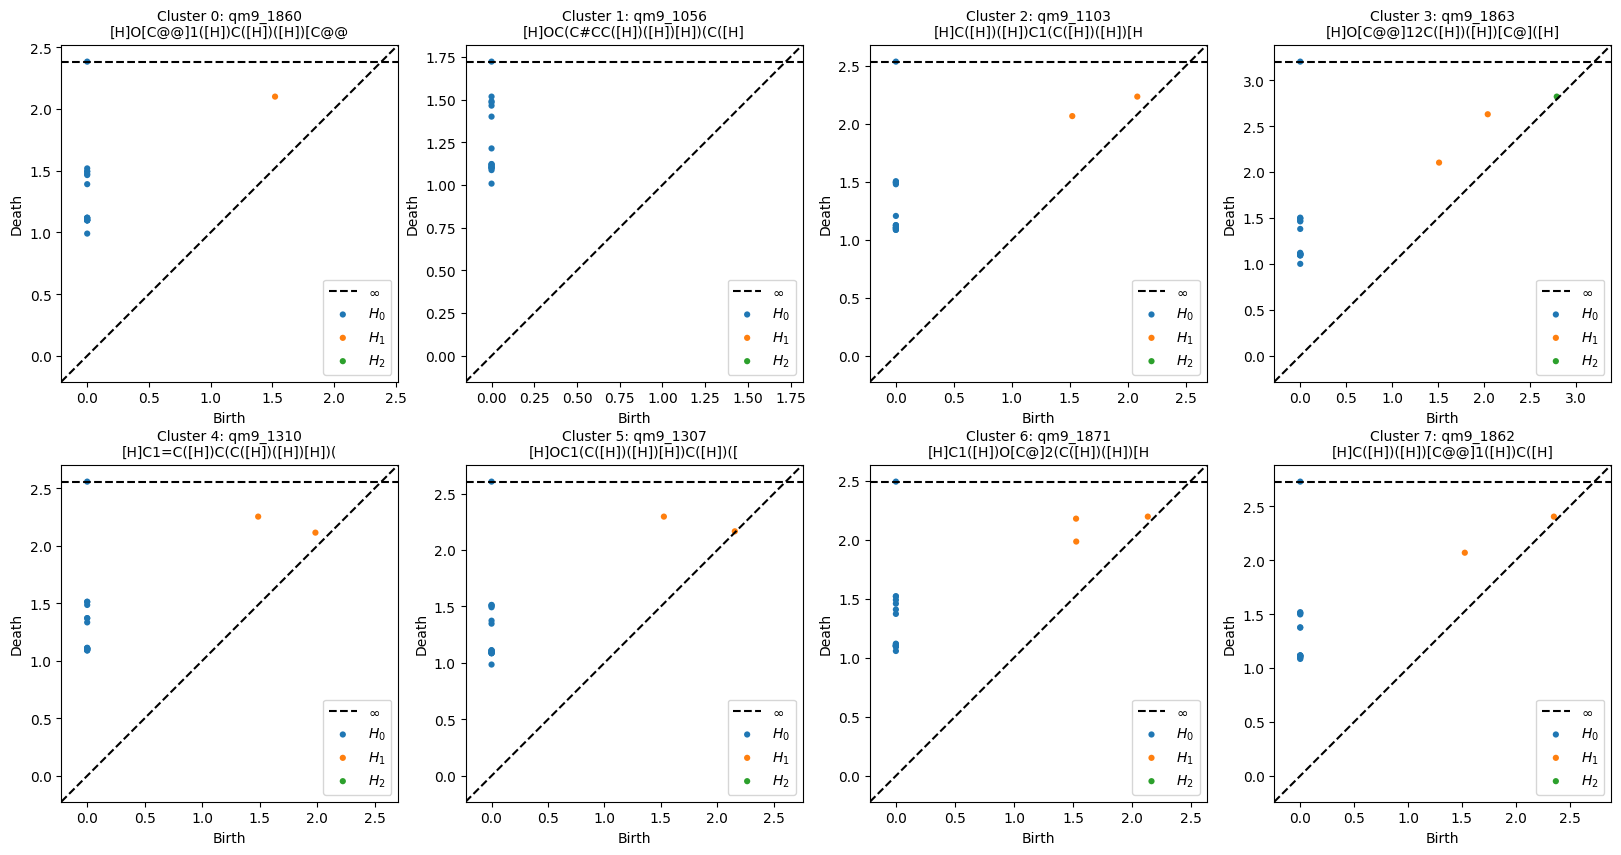

In [23]:
diagrams = PersistentHomology.compute_persistence_diagrams(frames)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

unique_clusters = sorted(isomers_df["cluster_ph"].unique().to_list())
n = 0

for i, cluster_nr in enumerate(unique_clusters):
    cluster_sample = isomers_df.with_row_index().filter(pl.col("cluster_ph") == cluster_nr).head(1)
    
    idx = cluster_sample["index"][n]
    mol_id = cluster_sample["mol_id"][n]
    smiles = cluster_sample["smiles"][n]
    
    dgms_dict = diagrams[idx]
    dgms = [dgms_dict.get(dim, np.empty((0, 2))) for dim in range(3)]
    
    plt.sca(axes[i])
    plot_diagrams(dgms, show=False)
    axes[i].set_title(f"Cluster {cluster_nr}: {mol_id}\n{smiles[:30]}", fontsize=10)



plt.tight_layout()
plt.show()


# SOAP

In [ ]:
properties = {
    "UMAP 1": X_soap_t[:, 0],
    "UMAP 2": X_soap_t[:, 1],
    "Cluster": labels_soap,
    "Structure": isomers_df["structure_class"].to_list(),
    "Functional Groups":  isomers_df["functional_groups"].to_list(),
    "SP1 Carbon" : isomers_df["num_sp_carbons"].to_list(),
    "SP2 Carbon" : isomers_df["num_sp2_carbons"].to_list(),
    "SP3 Carbon" : isomers_df["num_sp3_carbons"].to_list(),
}

widget = chemiscope.show(
    structures=frames,
    properties=properties,
)

widget

<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 17, 'data': 'structure-0'}, {'size': 17, 'data': 's…